In [17]:
import pandas as pd
import os

import sys
sys.path.append(os.path.abspath('/mlbio_scratch/anagupta/luna/LUNA'))

from metrics.evaluation_plot import plot_scatter_visualization, plot_scatter_visualization_custom
from align import process_directories, align_point_clouds2

from utils.data.load import (
    cell_class_decoding,
    compute_distance,
    position_normalize,
    to_dataframe,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np

data_dir = '/mlbio_scratch/anagupta/xenium_preprocessed/sliced_data'

images = np.load(os.path.join(data_dir, 'slice_images.npz'), allow_pickle=True)
print("Loaded images: ", images.keys())

Loaded images:  KeysView(NpzFile '/mlbio_scratch/anagupta/xenium_preprocessed/sliced_data/slice_images.npz' with keys: wildtype_5_7__1, wildtype_5_7__2, wildtype_5_7__3, wildtype_5_7__4, wildtype_5_7__5...)


In [3]:
output_dir = '/mlbio_scratch/anagupta/luna/runs/baseline_sliced/2025-07-02_16-12-52/test_results/test/model_2025-07-02_epoch_999/TgCRND8_5_7__11_0' 
output_dir = '/mlbio_scratch/anagupta/luna/runs/baseline_sliced/2025-07-02_16-12-52/test_results/test/model_2025-07-02_epoch_999/TgCRND8_5_7__9_0'

slice_name = '_'.join(output_dir.rstrip('/').split('/')[-1].split('_')[:-1])

print(slice_name)

TgCRND8_5_7__9


In [35]:
directories = [output_dir]

process_directories(directories)

Processed and saved aligned predictions for /mlbio_scratch/anagupta/luna/runs/baseline_sliced/2025-07-02_16-12-52/test_results/test/model_2025-07-02_epoch_999/TgCRND8_5_7__9_0


In [ ]:
img = images[slice_name]

950
[[-0.05808556 -0.23915604]
 [-0.06465763 -0.26913297]
 [-0.35989687 -0.11900985]
 ...
 [-0.11277178 -0.27979136]
 [-0.16731313 -0.18709895]
 [-0.36526042 -0.10714555]]


In [ ]:
pred_df = pd.read_csv(output_dir + '/metadata_pred.csv', index_col=0)
true_df = pd.read_csv(output_dir + '/metadata_true.csv', index_col=0)
shape_df = pd.read_csv(output_dir + '/metadata_shape.csv', index_col=0)


pred_coords = pred_df[['coord_X', 'coord_Y']].values
num_samples = pred_coords.shape[0]
print(num_samples)
print(pred_coords)

In [36]:
aligned_df = pd.read_csv(output_dir + '/metadata_pred_aligned.csv', index_col=0)

In [ ]:
# plot img 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title(f"Slice image: {slice_name}")
plt.axis('off')
plt.show()

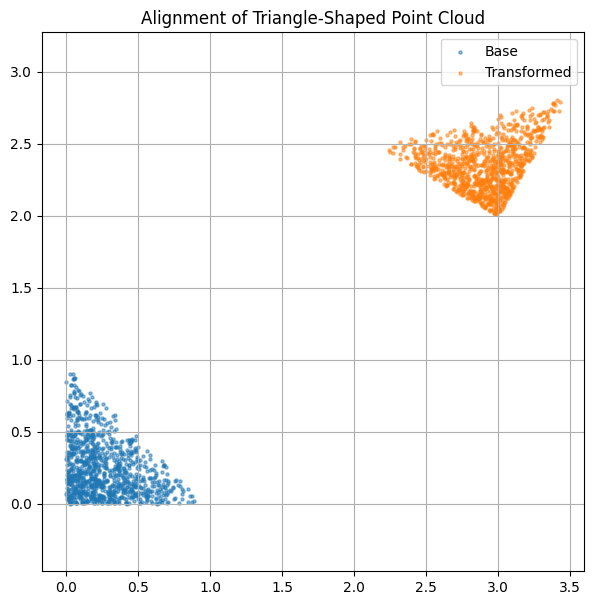

In [26]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
from scipy.linalg import svd

def align_point_clouds3(base, target):
    """
    Align target to base using Procrustes analysis with reflection (flip) correction.
    No scaling is applied.
    """
    # Center both point clouds
    base_mean = base.mean(0)
    target_mean = target.mean(0)
    base_centered = base - base_mean
    target_centered = target - target_mean

    # SVD to get optimal rotation/reflection
    H = target_centered.T @ base_centered
    U, _, Vt = svd(H)
    R = U @ Vt

    # Check for reflection (det(R) < 0) → flip correction
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = U @ Vt

    # Apply transformation
    aligned_target = target_centered @ R + base_mean
    return aligned_target

def align_point_clouds_with_reflection_option(base, target):
    """
    Aligns target to base by trying both with and without horizontal flip.
    Returns the best alignment based on mean squared error.
    """
    def align(base, target):
        base_mean = base.mean(0)
        target_mean = target.mean(0)
        base_centered = base - base_mean
        target_centered = target - target_mean

        H = target_centered.T @ base_centered
        U, _, Vt = svd(H)
        R = U @ Vt
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = U @ Vt

        aligned = target_centered @ R + base_mean
        return aligned

    aligned_normal = align(base, target)
    aligned_flipped = align(base, target * np.array([-1, 1]))  # horizontal flip

    error_normal = np.mean(np.linalg.norm(aligned_normal - base, axis=1))
    error_flipped = np.mean(np.linalg.norm(aligned_flipped - base, axis=1))

    if error_flipped < error_normal:
        return aligned_flipped
    else:
        return aligned_normal


def generate_right_triangle_cloud(num_points=1000):
    # Vertices of a right-angled triangle at the origin
    p1 = np.array([0, 0])
    p2 = np.array([1, 0])
    p3 = np.array([0, 1])
    points = []

    while len(points) < num_points:
        a, b, c = np.random.rand(3)
        if a + b + c <= 1:
            pt = a*p1 + b*p2 + c*p3
            points.append(pt)
    return np.array(points)


def test_align_point_clouds():
    base = generate_right_triangle_cloud()

    # Step 2: Apply transformation (flip, rotate, translate)
    target = np.copy(base)
    target[:, 0] *= -1  # Flip horizontally
    theta = np.radians(30)
    rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    target = target @ rot
    target += np.array([3, 2])  # Translate

    # Step 3: Align
    aligned = align_point_clouds_with_reflection_option(base, target)

    # Step 4: Plot
    plt.figure(figsize=(7, 7))
    plt.scatter(base[:, 0], base[:, 1], s=5, label="Base", alpha=0.5)
    plt.scatter(target[:, 0], target[:, 1], s=5, label="Transformed", alpha=0.5)
    # plt.scatter(aligned[:, 0], aligned[:, 1], s=5, label="Aligned", alpha=0.5)
    plt.legend()
    plt.axis("equal")
    plt.title("Alignment of Triangle-Shaped Point Cloud")
    plt.grid(True)
    plt.show()

test_align_point_clouds()


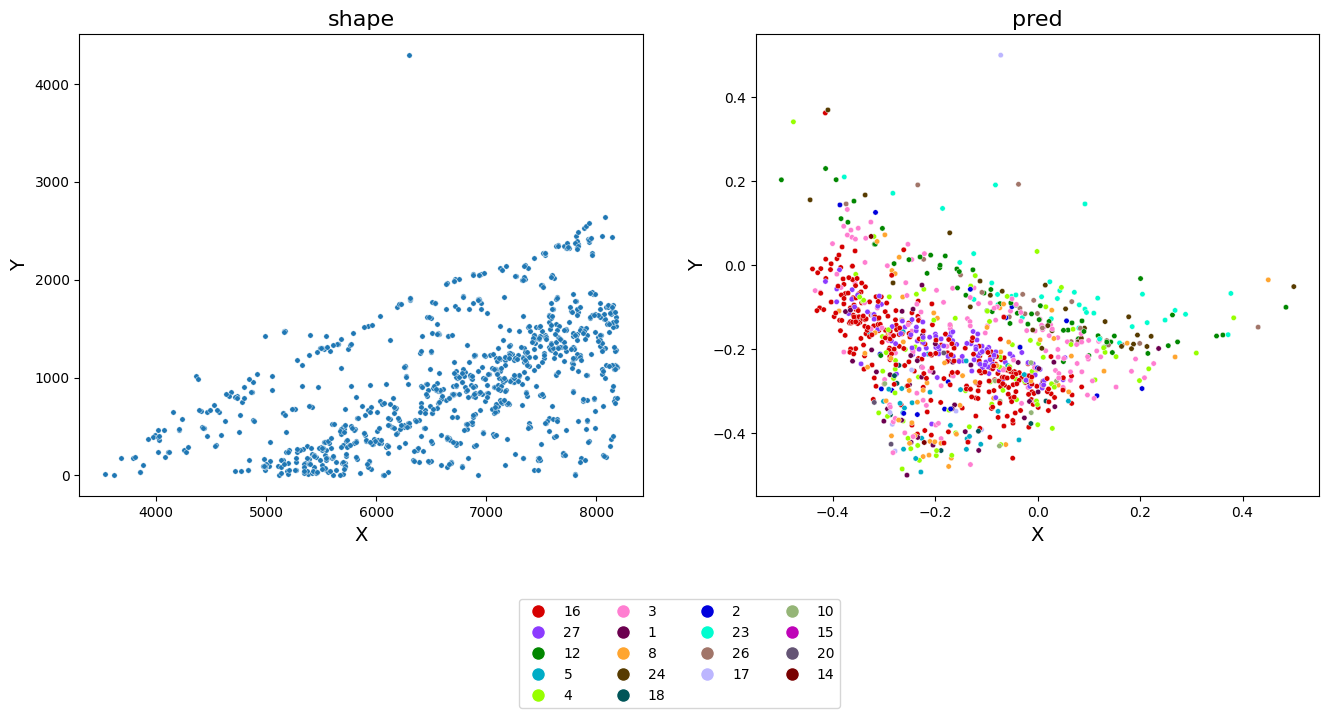

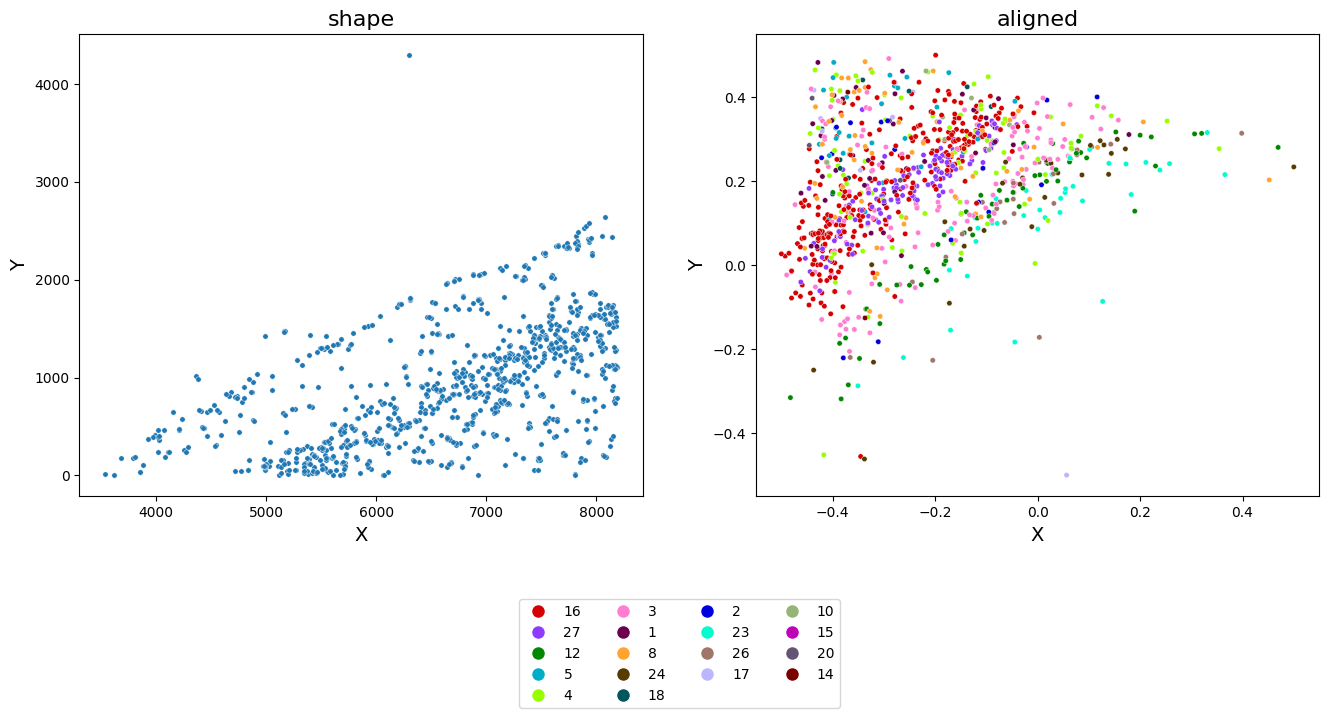

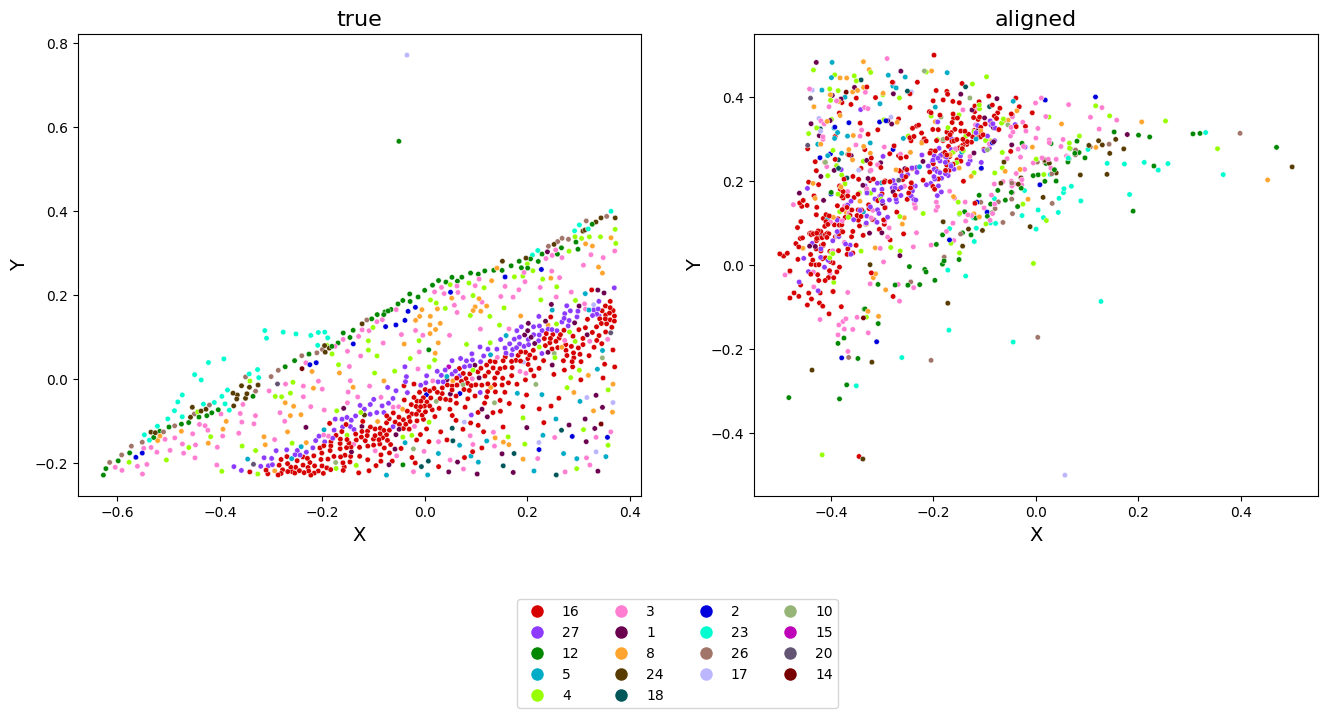

In [37]:
unique_classes = true_df['cell_class'].unique()
os.makedirs(output_dir, exist_ok=True)
# plot_scatter_visualization(pred_df, aligned_df, unique_classes, output_dir)
plot_scatter_visualization_custom(shape_df, pred_df, output_dir, "shape", "pred")

aligned_df = position_normalize(aligned_df)
plot_scatter_visualization_custom(shape_df, aligned_df, output_dir, "shape", "aligned")

plot_scatter_visualization_custom(true_df, aligned_df, output_dir, "true", "aligned")

Detected 3527 bright spots (putative nuclei)


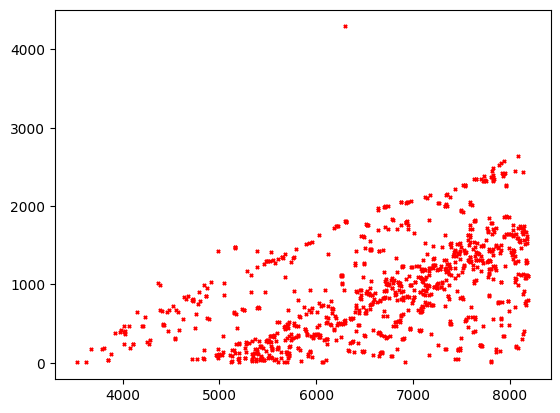

In [5]:
import numpy as np
import imageio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
import os

image = img
sigma = 5  # Controls the spatial extent of each cell's "influence"
min_distance = 5  # Minimum distance between real detected peaks
intensity_threshold = 10  # Adjust this to ignore low-intensity noise

# Step 1: Detect bright nuclei-like peaks
coordinates = peak_local_max(
    image,
    min_distance=min_distance,
    threshold_abs=intensity_threshold
)

print(f"Detected {len(coordinates)} bright spots (putative nuclei)")

# Step 2: Create density map (impulses at nuclei locations)
density_map = np.zeros_like(image, dtype=np.float32)
for y, x in coordinates:
    density_map[y, x] = 1.0

# Step 3: Smooth with Gaussian to create spatial probability map
prob_map = gaussian_filter(density_map, sigma=sigma)

# Step 4: Normalize to get a proper probability distribution
prob_map /= prob_map.sum()

# Step 5: Flatten and sample pixel indices based on the probability
flat_probs = prob_map.ravel()
sampled_indices = np.random.choice(
    len(flat_probs), size=num_samples, replace=True, p=flat_probs
)

# Step 6: Convert flat indices to 2D coordinates
H, W = image.shape
ys, xs = np.unravel_index(sampled_indices, (H, W))
coordinates = np.array([[x, y] for x, y in zip(xs, ys)])
point_cloud = np.zeros((8192, 8192))
point_cloud[ys, xs] = 1

# plot the point cloud
# plt.imshow(point_cloud, cmap='gray')
plt.scatter(coordinates[:, 0], coordinates[:, 1], marker='x', color='red', s=5)
plt.show()



In [6]:
# Save the sampled coordinates as a CSV file
coords_df = pd.DataFrame(coordinates, columns=['coord_X', 'coord_Y'])
coords_df.to_csv(os.path.join(output_dir, 'metadata_shape.csv'), index=False)

In [30]:
shape_df['coord_X'] = shape_df.index

In [31]:
pred_coords = aligned_df[['coord_X', 'coord_Y']].to_numpy()
coordinates = shape_df[['coord_X', 'coord_Y']].to_numpy()

In [32]:
from scipy.optimize import linear_sum_assignment
import ot

# Cost matrix
M = ot.dist(pred_coords[:, :2], coordinates[:, :2], metric='euclidean')**2

# One-to-one assignment
row_ind, col_ind = linear_sum_assignment(M)

# Map each predicted point to one target point
matched_pts = []
for row, col in zip(row_ind, col_ind):
    matched_pts.append((pred_df.iloc[row]['cell_class'], coordinates[col, 0], coordinates[col, 1]))
    # create final dataframe with the matched points
    final_df = pd.DataFrame(matched_pts, columns=['cell_class', 'coord_X', 'coord_Y'])
    # final_df.to_csv(output_dir + '/matched_points.csv', index=False)
matched_pts = np.array(matched_pts)

print(matched_pts.shape)
print(final_df.head())

(950, 3)
   cell_class  coord_X  coord_Y
0        16.0     7360     1163
1        16.0     7318     1310
2        16.0     4982      170
3        27.0     6188      433
4        16.0     5201      126


In [33]:
unique_classes = final_df['cell_class'].unique()
os.makedirs(output_dir, exist_ok=True)

# final_df[['coord_X', 'coord_Y']] = (final_df[['coord_X', 'coord_Y']] - final_df[['coord_X', 'coord_Y']].min()) / (final_df[['coord_X', 'coord_Y']].max() - final_df[['coord_X', 'coord_Y']].min())
final_df = position_normalize(final_df)

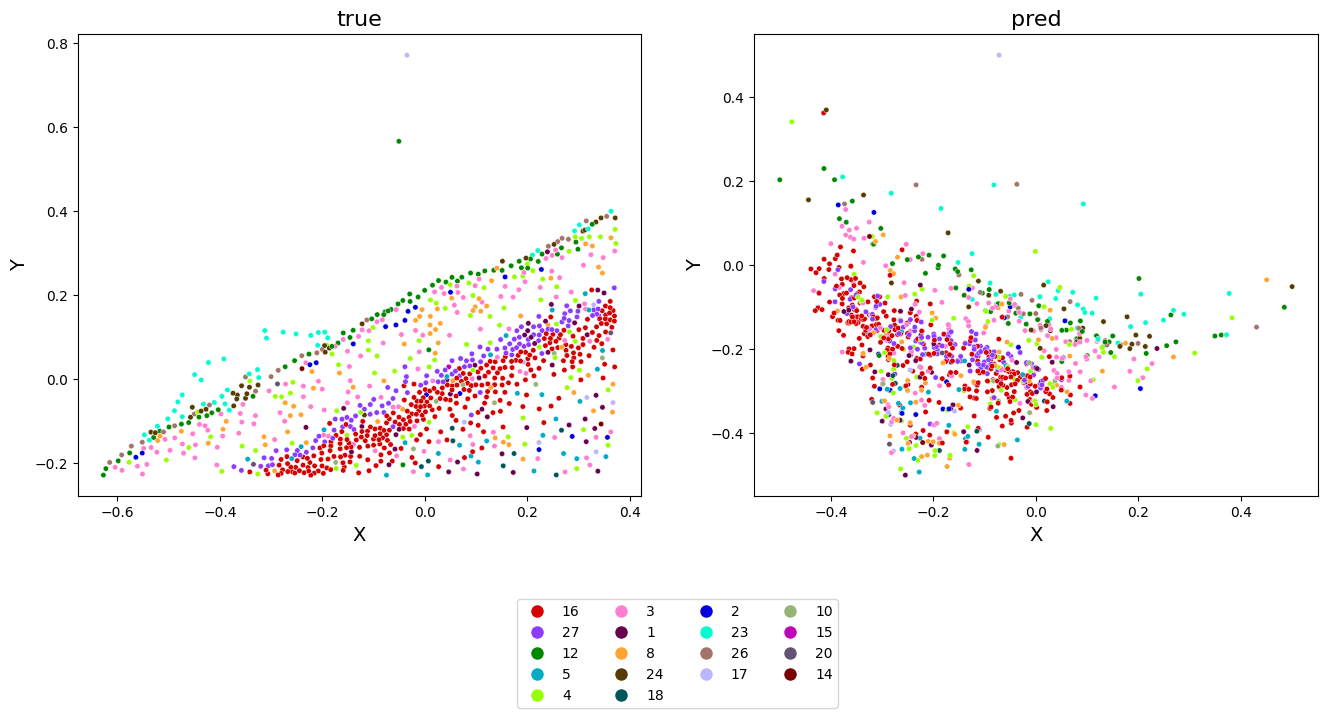

In [38]:
plot_scatter_visualization_custom(true_df, pred_df, output_dir, "true", "pred")

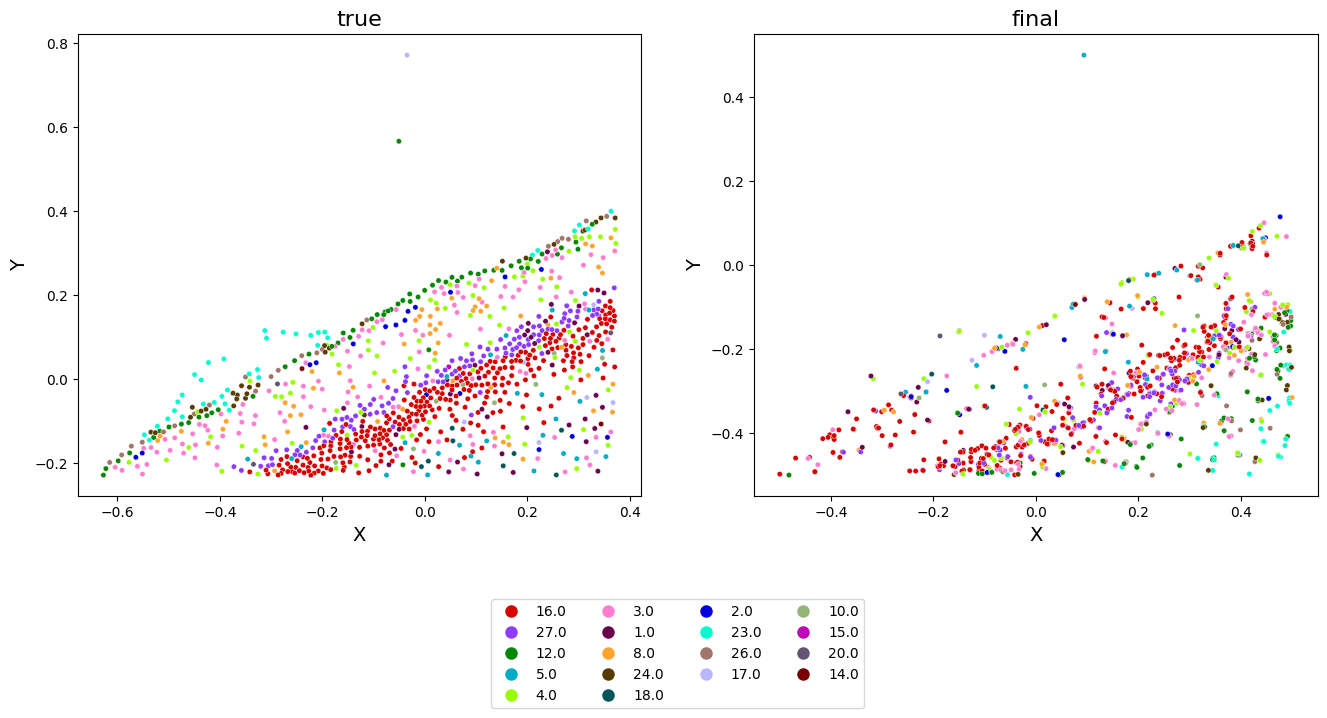

In [34]:
plot_scatter_visualization_custom(true_df, final_df, output_dir, "true", "final")

In [ ]:
import os

base_dir = '/mlbio_scratch/anagupta/luna/runs/baseline_sliced/2025-07-03_07-06-50/test_results/test/model_2025-07-03_epoch_999'
    
for sub_dir in os.listdir(base_dir):
    if sub_dir.startswith("TgCRND8") or sub_dir.startswith("wildtype"):
        dir = os.path.join(base_dir, sub_dir)
        directories.append(dir)

unknown_0
test_results.csv
TgCRND8_17_9__12_0
TgCRND8_2_5__8_0
TgCRND8_17_9__8_0
wildtype_13_4__12_0
wildtype_2_5__4_0
TgCRND8_5_7__4_0
wildtype_5_7__4_0
wildtype_13_4__4_0
unknown_1
wildtype_2_5__8_0
wildtype_5_7__8_0
unknown_2
TgCRND8_2_5__4_0
TgCRND8_5_7__8_0
wildtype_13_4__8_0
wildtype_5_7__12_0
TgCRND8_17_9__12_1
